In [310]:
## IMPORTS

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer

In [311]:
##importing data set
df = pd.read_csv("../data/machine_failure_dataset_cleaned.csv")

# **ANALYSING, CLEANING & EDA**

ANALYSIS

In [312]:
df.head()

,product_ID,product_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,power_failure,overstrain_failure
0,H29424,H,298.4,308.9,1782.0,23.9,24,0,0,0,0
1,H29425,H,298.6,309.1,1423.0,44.3,29,0,0,0,0
2,H29432,H,298.8,309.2,1306.0,54.5,50,0,0,0,0
3,H29434,H,298.9,309.3,1375.0,42.7,58,0,0,0,0
4,H29441,H,299.1,309.4,1811.0,24.6,77,0,0,0,0


In [313]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_ID             1081 non-null   str    
 1   product_type           1081 non-null   str    
 2   air_temperature_k      1072 non-null   float64
 3   process_temperature_k  1075 non-null   float64
 4   rotational_speed_rpm   1080 non-null   float64
 5   torque_nm              1074 non-null   float64
 6   tool_wear_min          1081 non-null   int64  
 7   machine_failure        1081 non-null   int64  
 8   tool_wear_failure      1081 non-null   int64  
 9   power_failure          1081 non-null   int64  
 10  overstrain_failure     1081 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 93.0 KB


In [314]:
df.describe()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,power_failure,overstrain_failure
count,1072.000000,1075.000000,1080.000000,1074.000000,1081.000000,1081.000000,1081.000000,1081.000000,1081.000000
mean,297.426679,308.288744,1539.454630,41.476164,108.653099,0.022202,0.000925,0.012951,0.009251
std,0.940060,0.976013,181.580554,29.685232,63.557417,0.147407,0.030415,0.113115,0.095779
min,295.300000,305.700000,1168.000000,4.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,296.800000,307.800000,1424.750000,33.200000,54.000000,0.000000,0.000000,0.000000,0.000000
50%,297.500000,308.400000,1503.000000,40.100000,110.000000,0.000000,0.000000,0.000000,0.000000
75%,298.100000,309.000000,1611.000000,46.475000,163.000000,0.000000,0.000000,0.000000,0.000000
max,299.100000,310.200000,2874.000000,500.000000,240.000000,1.000000,1.000000,1.000000,1.000000


In [315]:
df.shape

(1081, 11)

In [316]:
df.columns

Index(['product_ID', 'product_type', 'air_temperature_k',
       'process_temperature_k', 'rotational_speed_rpm', 'torque_nm',
       'tool_wear_min', 'machine_failure', 'tool_wear_failure',
       'power_failure', 'overstrain_failure'],
      dtype='str')

In [317]:
## There is a huge imbalance, **MUST DO CLASS=BALANCED**

df["machine_failure"].value_counts()

machine_failure
0    1057
1      24
Name: count, dtype: int64

In [318]:
df.isnull().sum()

product_ID               0
product_type             0
air_temperature_k        9
process_temperature_k    6
rotational_speed_rpm     1
torque_nm                7
tool_wear_min            0
machine_failure          0
tool_wear_failure        0
power_failure            0
overstrain_failure       0
dtype: int64

CLEANING


In [319]:
## SQL handled most of the cleaning, PYTHON will deal with NULL values(simple imputer, during pipeline building) and Outliers(during EDA)

In [320]:
##REMOVING unwanted columns, product_ID is only an identifier and it has no predictive value.

df = df.drop("product_ID", axis=1)

**EXPLORITORY DATA ANALYSIS**

In [321]:
## Separating numerical and categorical columns

numerical_columns = ["air_temperature_k",
                     "process_temperature_k",
                     "rotational_speed_rpm",
                     "torque_nm",
                     "tool_wear_min"
                     

]
categorical_columns = [
                        "product_type",
                        "tool_wear_failure",
                        "power_failure",
                        "overstrain_failure"
    
]

DISTRIBUTION
- help up understand how the data is distributed

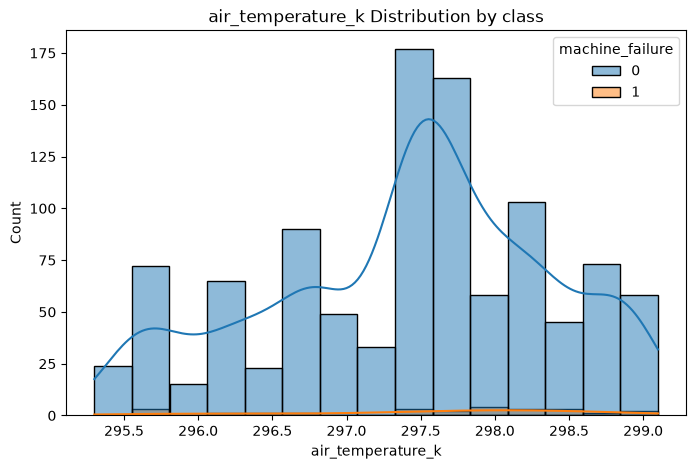

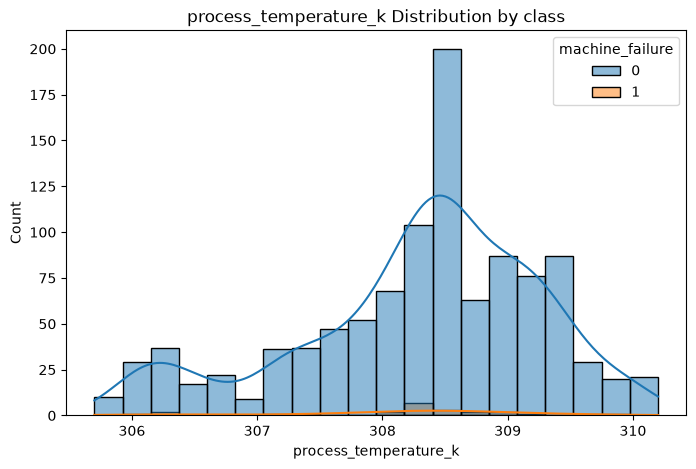

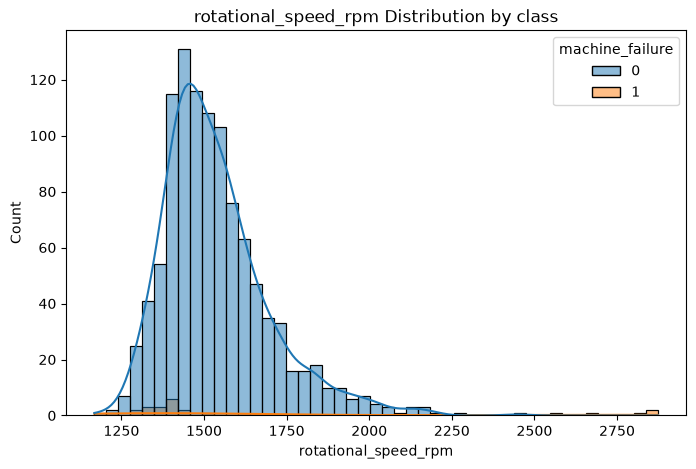

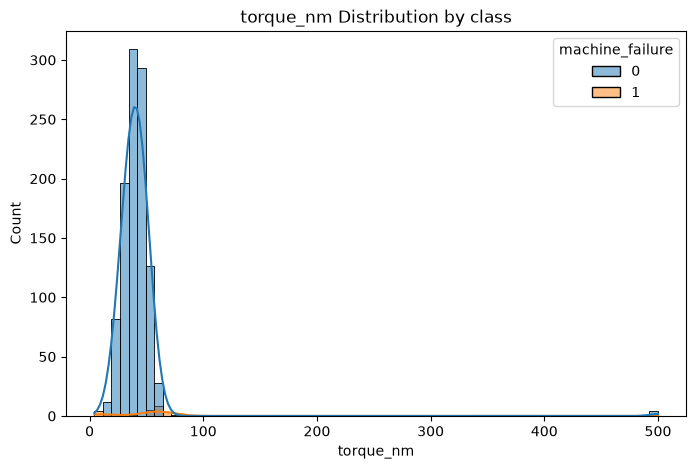

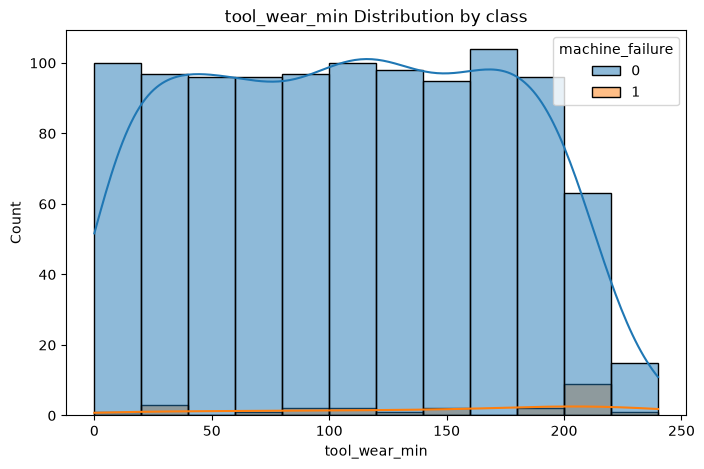

In [322]:
## Histogram (for numerical values)

for column in numerical_columns:
    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=column,
        hue="machine_failure",
        kde = True   
    )

    plt.title(f"{column} Distribution by class")
    plt.show()


Observation:

- air_temperature_k: shows a multimodal shape and failure are rare however there is a slight increan of failures forming a bell shape from 296.7 to 299
  
- process_temperature_k: multimodal and left-skewed, failures are rare however there is a slight increase of failures forming a bell shape from 307.5 to 309.5 of failures between
 
- rotational_speed_rpm: right skewed with a few outliers, failures are rare however they show a small left skewed shape in the beggining of the graph
- torque_nm: bell shape, left skewed a little bit, failures are still rare however they show a small bell shape from 40 to 90
- tool_wear_min: rectangle shape, right skewed a little, failures are rare howeever they form a small left skewed graph

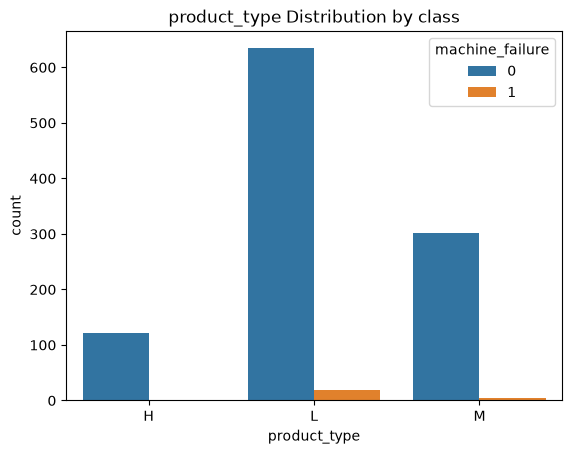

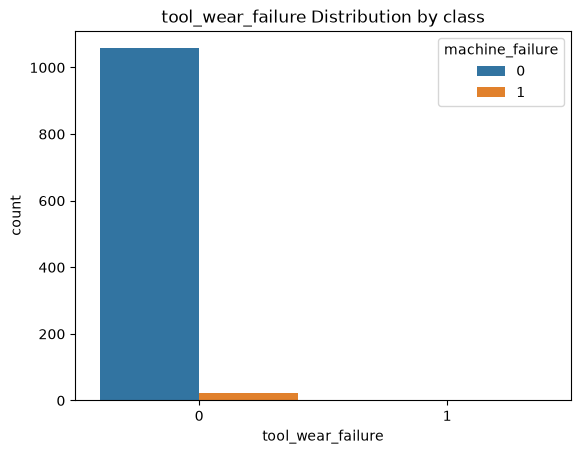

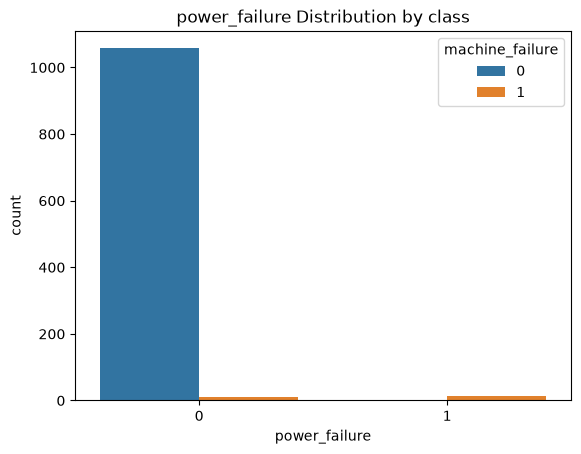

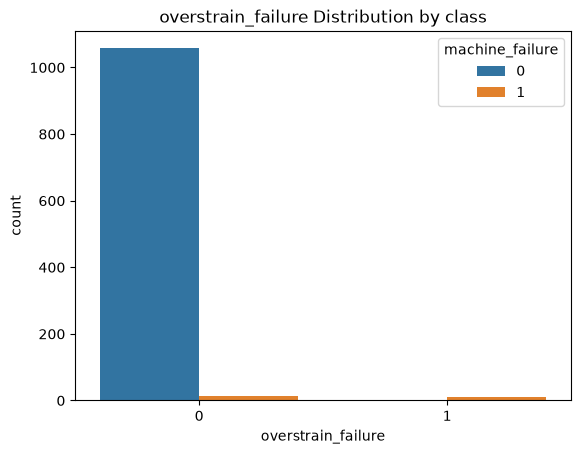

In [323]:
## Count plot(for categorical values)

for column in categorical_columns:
    plt.figure()

    sns.countplot(
        data=df,
        x=column,
        hue="machine_failure"
    )

    plt.title(f"{column} Distribution by class")
    plt.show()




Observation:

- product_type: machine failure are less common for the product type H (High) and most common for product type L (Low), Medium (M) failures are less than product type L and more than product type H. 

- tool_wear_failure: The graph shows that most observations do not have a tool wear failure, only a small number of machine_failures occurred when there was no recorded tool wear failure, this suggests that tool wear failure is not common in the dataset.

- power_failure: The graph shows a few machine failure observations both when there is a power failure and when there is no power failure.

- overstrain_failure: The graph shows a few machine failure observations both when there is a overstrain failure and when there is no overstrain failure, indicating that machine failure occur when overstrain failure is present or not.


OUTLIER DETECTION
- While observing the distribution graphs we have discoverd that some numerical columns may contain outliers

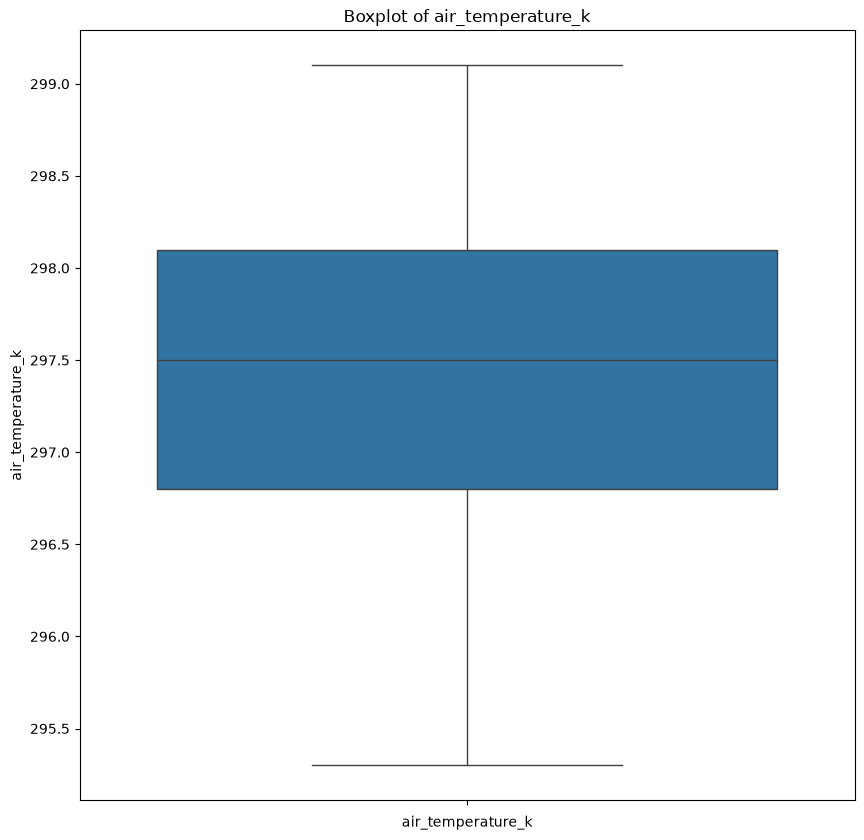

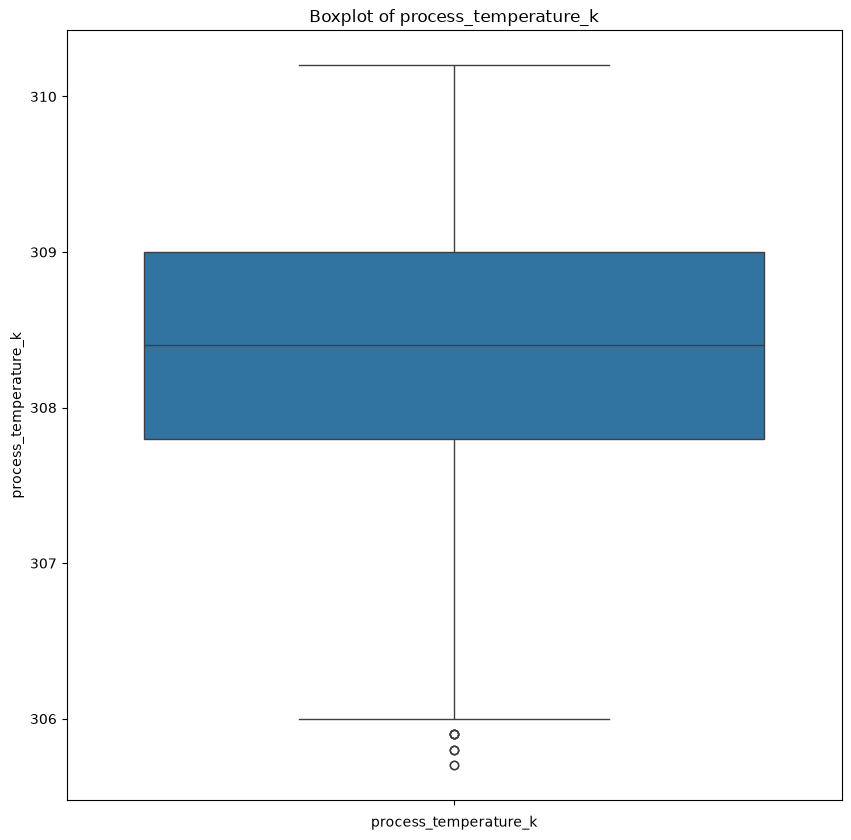

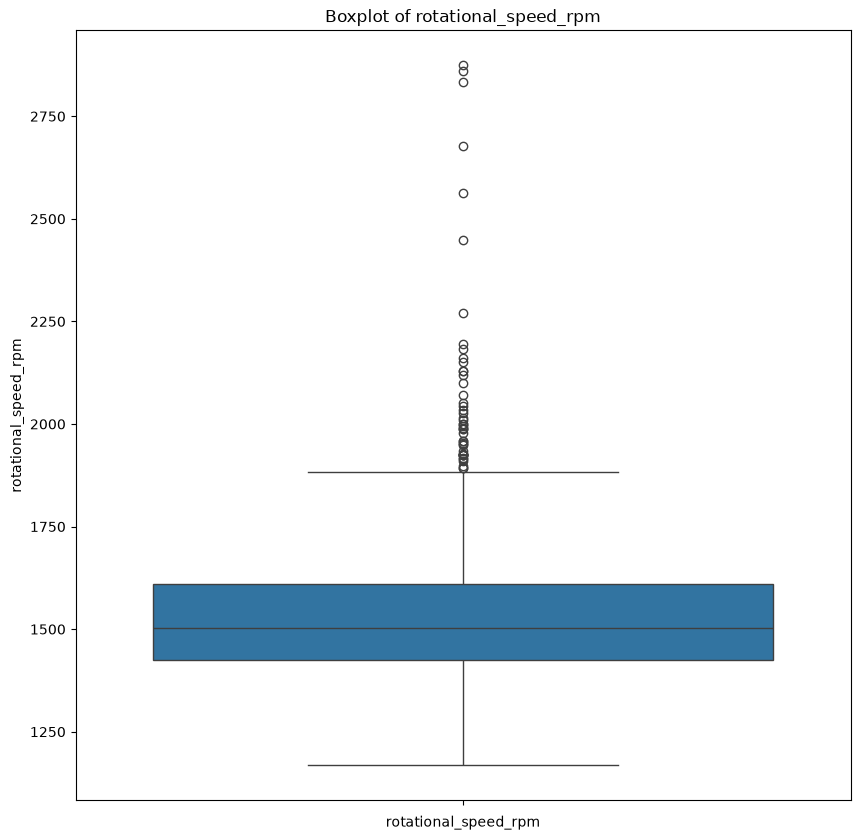

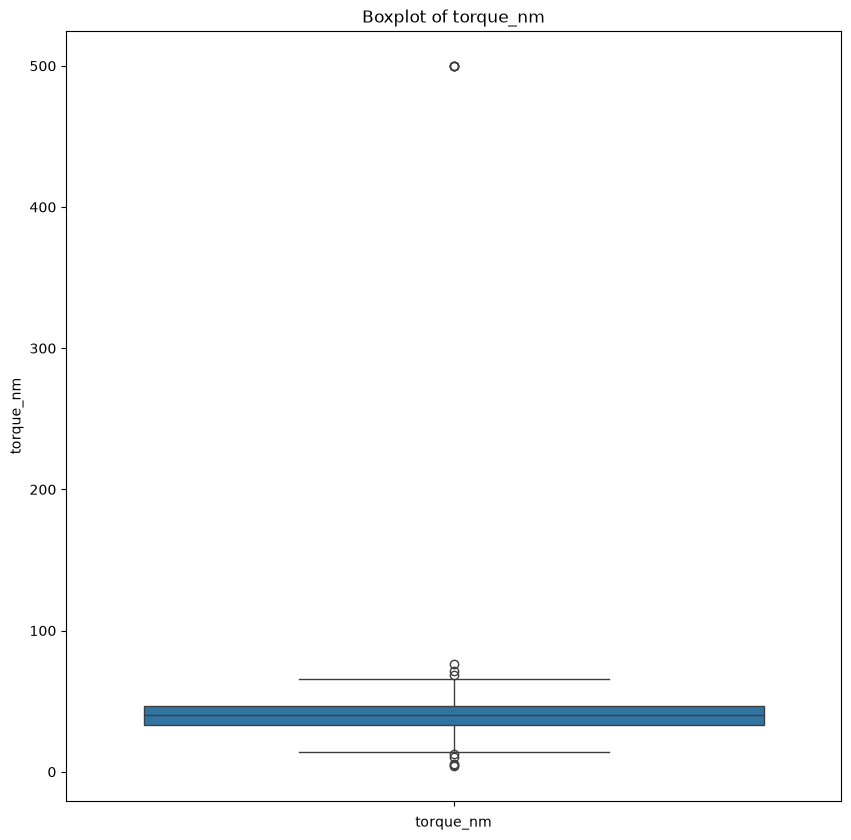

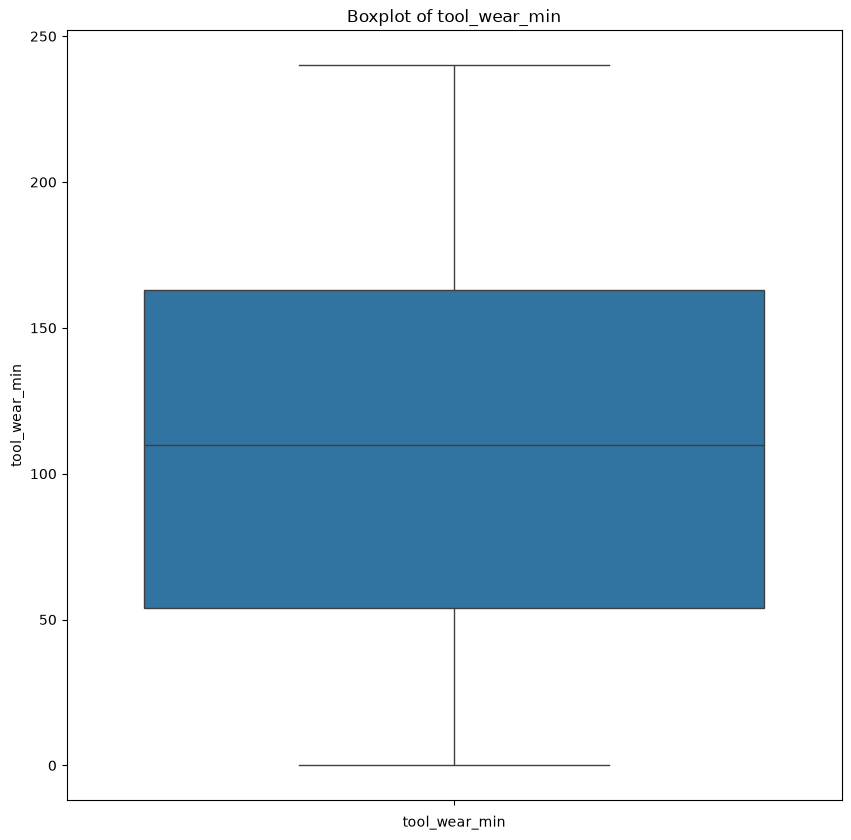

In [324]:
## Boxplot to see weather a feature contains outliers
for column in numerical_columns:
    plt.figure(figsize=(10,10))

    sns.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(f'{column}')
    plt.show()

Observation:

- air_temperature_k: all values are within the whiskers, indicating that no outliers were detected
  
- process_temperature_k: a few values are clustered close to each other appear below the lower whisker, since these values are not extremely isolated this could suggest a natural variation

- rotational_speed_rpm: a few values are clustered close to each other above the upper whisker, these values do not appear to be isolated and this suggest a natural variation

- torque_nm: there are a few values that appear below the lower whisker and above the upper whisker these values are clustered close to each other, however ther is a single value that is isolated way above the other values above the upper whisker. this value was identified as an artificially introduced value during data preparation, therefore it will me removed

- tool_wear_min: all values are within the whiskers, indicating that no outliers were detected

REMOVING OUTLIERS

In [325]:
## Removing the artificially introduced torque value

df = df[df["torque_nm"] < 500]

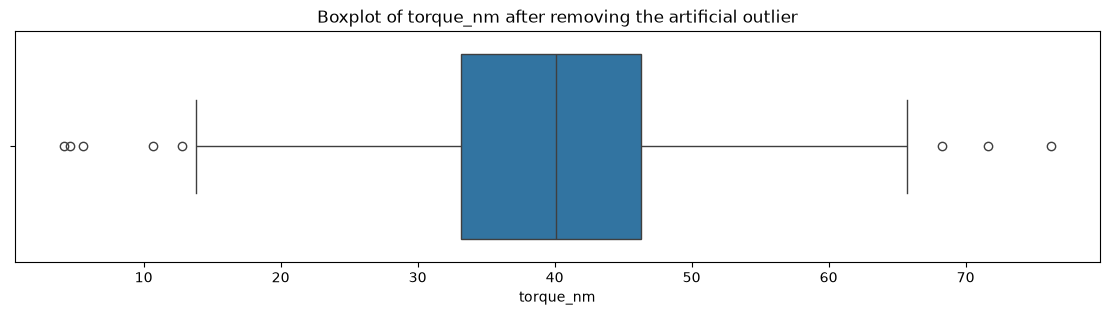

In [326]:
plt.figure(figsize=(14,3))
sns.boxplot(x=df["torque_nm"])
plt.title("Boxplot of torque_nm after removing the artificial outlier")
plt.show()

CORRELATION ANALYSIS

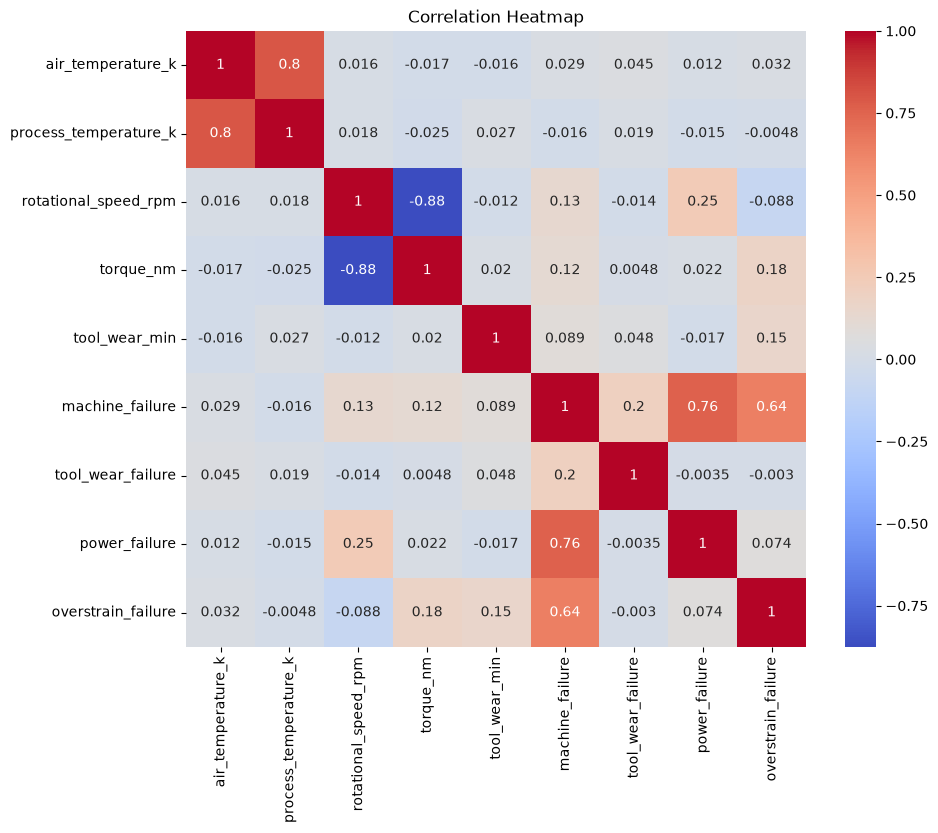

In [327]:
## Correlation analysis for numerical values
## Heatmap 

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only = True),
    annot = True,
    cmap = "coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Observation:

- process_temperature_k and air_temperature have a strong positive correlation of 0.8, this suggests that the two features are giving almost the same information so one could be considered for removal, process_temperature_k was chosen for removal because it has the lowest feature vs target correlation of - 0.016

- rotational_speed_rpm and torque_nm have a strong negative correlation of -0.88, rotational_speed_rpm could be considered for removal because it has i slightly weaker correlatrion with the target (0.13 vs 0.12)

- power_failure and overstrain_failure showed a positive correlation with the target, suggesting that they have a linear relationship and they will help the model make better predictions.

- the remaining features do not show any strong correlation and were therefore retained for model development

In [328]:
## process_temperature_k removal

df = df.drop("process_temperature_k", axis=1)

In [329]:
## rotational_speed_rpm removal 

df = df.drop("rotational_speed_rpm", axis=1)

In [330]:
df.head()


,product_type,air_temperature_k,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,power_failure,overstrain_failure
0,H,298.4,23.9,24,0,0,0,0
1,H,298.6,44.3,29,0,0,0,0
2,H,298.8,54.5,50,0,0,0,0
3,H,298.9,42.7,58,0,0,0,0
4,H,299.1,24.6,77,0,0,0,0


# **PIPELINE BUILDING**

In [331]:
## defining X and y

X = df.drop("machine_failure", axis=1)
y = df["machine_failure"]

TRAIN TEST SPLIT

In [332]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

PIPELINE BUILDING and Preprocessing

In [333]:
## RENEWING (Separating numerical and categorical columns)

numerical_columns = ["air_temperature_k",
                     "torque_nm",
                     "tool_wear_min"
]

categorical_columns = [
                        "product_type",
                        "tool_wear_failure",
                        "power_failure",
                        "overstrain_failure"
]

In [334]:
numerical_pipeline = Pipeline([
   ("imputer", SimpleImputer(strategy= "median")),
   ("scaler", StandardScaler()),
   ("poly", PolynomialFeatures())


])

In [335]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy= "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

PREPROCESSOR
Preprocessed data: prepared, cleaned, consistent and ready for machine learning to learn from

In [337]:
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])